In [25]:
import torch
import numpy as np

emb = torch.load(
    "embeddings/fold_4_embeddings.pt"
)

tissue_emb = emb["epoch99"]["tissue"]
plasma_emb = emb["epoch99"]["plasma"]


patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)

print(len(patients))

10


In [26]:
X = []
labels = []
modalities = []

for patient in patients:

    X.append(
        tissue_emb[patient].numpy()
    )
    labels.append(patient)
    modalities.append("Tissue")


    X.append(
        plasma_emb[patient].numpy()
    )
    labels.append(patient)
    modalities.append("Plasma")


X = np.stack(X)

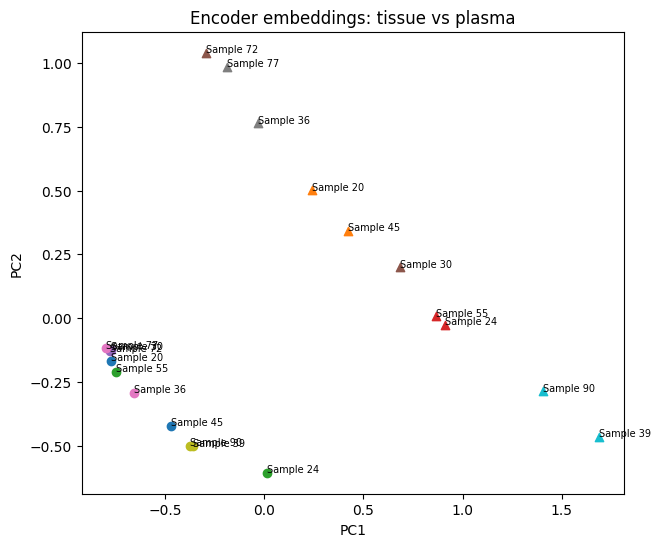

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)


plt.figure(figsize=(7,6))

for i in range(len(X_pca)):

    if modalities[i] == "Tissue":
        marker = "o"
    else:
        marker = "^"

    plt.scatter(
        X_pca[i,0],
        X_pca[i,1],
        marker=marker
    )

    plt.text(
        X_pca[i,0],
        X_pca[i,1],
        labels[i],
        fontsize=7
    )


plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Encoder embeddings: tissue vs plasma")

plt.show()

In [28]:
from sklearn.metrics.pairwise import cosine_distances

distances=[]

for patient in patients:

    d = cosine_distances(
        tissue_emb[patient].numpy().reshape(1,-1),
        plasma_emb[patient].numpy().reshape(1,-1)
    )[0,0]

    distances.append(d)


print(
    "Mean paired cosine distance:",
    np.mean(distances)
)
#
#

Mean paired cosine distance: 0.17256247


In [29]:
random_dist=[]

for i,p1 in enumerate(patients):

    p2 = patients[(i+1)%len(patients)]

    d = cosine_distances(
        tissue_emb[p1].numpy().reshape(1,-1),
        plasma_emb[p2].numpy().reshape(1,-1)
    )[0,0]

    random_dist.append(d)


print(
    "Mean random distance:",
    np.mean(random_dist)
)

Mean random distance: 0.19750069


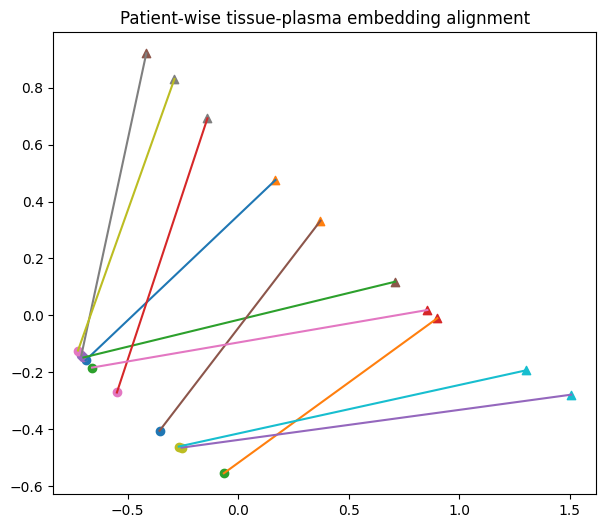

In [22]:
plt.figure(figsize=(7,6))


for patient in patients:

    t = pca.transform(
        tissue_emb[patient].numpy().reshape(1,-1)
    )[0]

    p = pca.transform(
        plasma_emb[patient].numpy().reshape(1,-1)
    )[0]


    plt.scatter(
        t[0],
        t[1],
        marker="o"
    )

    plt.scatter(
        p[0],
        p[1],
        marker="^"
    )


    plt.plot(
        [t[0],p[0]],
        [t[1],p[1]]
    )


plt.title(
    "Patient-wise tissue-plasma embedding alignment"
)

plt.show()